In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/imdb_top_1000.csv")
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [5]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Questions
1. crime and action movies whose rating is more than 8
2. Total gross amount of movies based on genre
3. number of movies released year wise
4. top rated movie of each year -- movies with similar ratings sort on the basis of number of votes
5. for drama genre year wise increase in gross amount -- percentage difference from previous year
6. Gross amount of movies based on runtime
7. Top 5 directors genre wise based on meta score and rating
8. Top 5 highest grossing actors
9. on the basis of certificate find avg rating and avg gross amount
10. year wise performance of "Christopher Nolan" on the basis of total gross amount, no. of votes, best performing movie on thew basis of gross amount

### Question1-: crime or action movies whose rating is more than 8

In [8]:
mask1=df["Genre"].str.contains("Crime")
mask2=df["Genre"].str.contains("Action")
mask3=mask1|mask2
temp_df=df[mask3]
mask4=temp_df["IMDB_Rating"]>8
ans=temp_df[mask4]
ans

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,https://m.media-amazon.com/images/M/MV5BZmY3MD...,Sanjuro,1962,U,96 min,"Action, Comedy, Crime",8.1,A crafty samurai helps a young man and his fel...,NaN,Akira Kurosawa,ToshirÃ´ Mifune,Tatsuya Nakadai,Keiju Kobayashi,YÃ»nosuke ItÃ´,33044,NaN
299,https://m.media-amazon.com/images/M/MV5BYTQ4Mj...,Les quatre cents coups,1959,NaN,99 min,"Crime, Drama",8.1,"A young boy, left without attention, delves in...",NaN,FranÃ§ois Truffaut,Jean-Pierre LÃ©aud,Albert RÃ©my,Claire Maurier,Guy Decomble,105291,NaN
305,https://m.media-amazon.com/images/M/MV5BY2I0MW...,On the Waterfront,1954,A,108 min,"Crime, Drama, Thriller",8.1,An ex-prize fighter turned longshoreman strugg...,91.0,Elia Kazan,Marlon Brando,Karl Malden,Lee J. Cobb,Rod Steiger,142107,"9,600,000"
308,https://m.media-amazon.com/images/M/MV5BZmI5NT...,White Heat,1949,NaN,114 min,"Action, Crime, Drama",8.1,A psychopathic criminal with a mother complex ...,NaN,Raoul Walsh,James Cagney,Virginia Mayo,Edmond O'Brien,Margaret Wycherly,29807,NaN


In [9]:
movies = df[
    (df['IMDB_Rating'] > 8) &
    ((df['Genre'].str.contains('Action')) |
    (df['Genre'].str.contains('Crime')))
]
movies

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,https://m.media-amazon.com/images/M/MV5BZmY3MD...,Sanjuro,1962,U,96 min,"Action, Comedy, Crime",8.1,A crafty samurai helps a young man and his fel...,NaN,Akira Kurosawa,ToshirÃ´ Mifune,Tatsuya Nakadai,Keiju Kobayashi,YÃ»nosuke ItÃ´,33044,NaN
299,https://m.media-amazon.com/images/M/MV5BYTQ4Mj...,Les quatre cents coups,1959,NaN,99 min,"Crime, Drama",8.1,"A young boy, left without attention, delves in...",NaN,FranÃ§ois Truffaut,Jean-Pierre LÃ©aud,Albert RÃ©my,Claire Maurier,Guy Decomble,105291,NaN
305,https://m.media-amazon.com/images/M/MV5BY2I0MW...,On the Waterfront,1954,A,108 min,"Crime, Drama, Thriller",8.1,An ex-prize fighter turned longshoreman strugg...,91.0,Elia Kazan,Marlon Brando,Karl Malden,Lee J. Cobb,Rod Steiger,142107,"9,600,000"
308,https://m.media-amazon.com/images/M/MV5BZmI5NT...,White Heat,1949,NaN,114 min,"Action, Crime, Drama",8.1,A psychopathic criminal with a mother complex ...,NaN,Raoul Walsh,James Cagney,Virginia Mayo,Edmond O'Brien,Margaret Wycherly,29807,NaN


## Q2 Total gross amount of movies based on genre

In [20]:
df1 = df.copy()

In [27]:
df["Genre"].str.split(",").str[2]

,Genre
0,NaN
1,NaN
2,Drama
3,NaN
4,NaN
...,...
995,Romance
996,NaN
997,War
998,NaN


In [21]:
df1["Genre1"] = df["Genre"].str.split(",").str[0]
df1["Genre2"] = df["Genre"].str.split(",").str[1]
df1["Genre3"] = df["Genre"].str.split(",").str[2]

In [29]:
df1[df1["Genre1"] == "Fantasy"]

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Genre1,Genre2,Genre3
321,https://m.media-amazon.com/images/M/MV5BNWJiNG...,Das Cabinet des Dr. Caligari,1920,NaN,76 min,"Fantasy, Horror, Mystery",8.1,"Hypnotist Dr. Caligari uses a somnambulist, Ce...",NaN,Robert Wiene,Werner Krauss,Conrad Veidt,Friedrich Feher,Lil Dagover,57428,NaN,Fantasy,Horror,Mystery
568,https://m.media-amazon.com/images/M/MV5BMTAxYj...,Nosferatu,1922,NaN,94 min,"Fantasy, Horror",7.9,Vampire Count Orlok expresses interest in a ne...,NaN,F.W. Murnau,Max Schreck,Alexander Granach,Gustav von Wangenheim,Greta SchrÃ¶der,88794,NaN,Fantasy,Horror,NaN


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [30]:
grp1 = df1.groupby(by = "Genre1")["Gross"].mean()
grp1

TypeError: agg function failed [how->mean,dtype->object]

In [32]:
df["Gross"].fillna(0, inplace = True)

/tmp/ipython-input-12163489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gross"].fillna(0, inplace = True)


In [34]:
data = []
for i in df["Gross"]:
  try:
    int(i)
  except:
    # print(i)
    data.append(i)

In [35]:
len(data)

831

In [43]:
df1["Gross"] = df1["Gross"].str.replace(",", "")
df1["Gross"].fillna(0, inplace = True)
df1["Gross"] = df1["Gross"].astype("int")

/tmp/ipython-input-1678914202.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1["Gross"].fillna(0, inplace = True)


In [51]:
df1["Genre1"] = df["Genre"].str.split(",").str[0].str.strip()
df1["Genre2"] = df["Genre"].str.split(",").str[1].str.strip()
df1["Genre3"] = df["Genre"].str.split(",").str[2].str.strip()

In [52]:
grp1 = df1.groupby(by = "Genre1")["Gross"].sum()
grp2 = df1.groupby(by = "Genre2")["Gross"].sum()
grp3 = df1.groupby(by = "Genre3")["Gross"].sum()

In [57]:
result_df = pd.concat([grp1, grp2, grp3], axis = 1).sum(axis = 1)/1000000
result_df.sort_values(ascending=False)

,0
Adventure,28174.317369
Drama,27497.622629
Action,22033.328131
Comedy,12247.931579
Sci-Fi,9029.610220
Animation,8573.824407
Crime,6956.303927
Thriller,6454.428931
Fantasy,6082.543147
Biography,5304.577796


<Axes: xlabel='None', ylabel='None'>

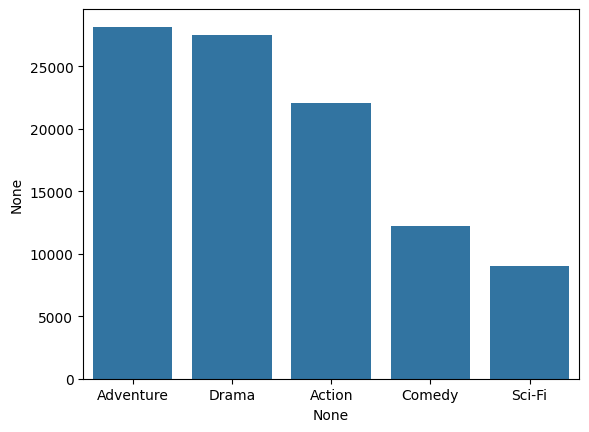

In [58]:
temp_df = result_df.sort_values(ascending=False).head()
sns.barplot(x = temp_df.index, y = temp_df)

## Qusetion 3 number of movies released year wise

In [59]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [62]:
for i in df["Released_Year"]:
  try:
    int(i)
  except:
    print(i)

PG


In [64]:
mask = df["Released_Year"] == "PG"
df.loc[mask, "Released_Year"] = 1995
df[mask]

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,1995,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [68]:
df["Released_Year"] = df["Released_Year"].astype("int")
# df["Gross"] = df["Gross"].astype("int")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   int64  
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   object 
dtypes: float64(2), int64(2), object(12)
memory usage: 125.1+ KB


In [70]:
temp_df = df.groupby(by = "Released_Year", as_index = False)["Series_Title"].count()
temp_df

,Released_Year,Series_Title
0,1920,1
1,1921,1
2,1922,1
3,1924,1
4,1925,2
...,...,...
94,2016,28
95,2017,22
96,2018,19
97,2019,23


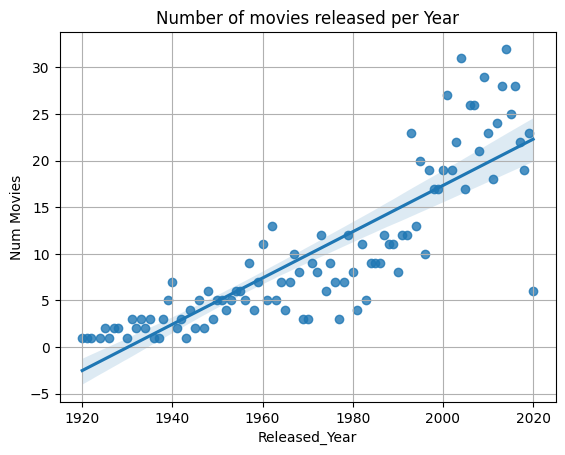

In [73]:
sns.regplot(temp_df, x = "Released_Year", y = "Series_Title",
             marker = "o")
plt.grid(True)
plt.ylabel("Num Movies")
plt.title("Number of movies released per Year")
plt.show()

## Question4 top rated movie of each year -- movies with similar ratings sort on the basis of number of votes

In [74]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [88]:
rating_rank = df.groupby(by = "Released_Year")["IMDB_Rating"].rank(method = "min",
                                                         ascending = False)
mask = rating_rank == 1
temp_df = df[mask]
temp_df = temp_df.sort_values(by = ["Released_Year",
                                    "No_of_Votes"], ascending = False)

temp_df.drop_duplicates(subset = ["Released_Year",
                                    "IMDB_Rating"], keep = "first")


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
18,https://m.media-amazon.com/images/M/MV5BNjViNW...,Hamilton,2020,PG-13,160 min,"Biography, Drama, History",8.6,The real life of one of America's foremost fou...,90.0,Thomas Kail,Lin-Manuel Miranda,Phillipa Soo,Leslie Odom Jr.,RenÃ©e Elise Goldsberry,55291,0
19,https://m.media-amazon.com/images/M/MV5BYWZjMj...,Gisaengchung,2019,A,132 min,"Comedy, Drama, Thriller",8.6,Greed and class discrimination threaten the ne...,96.0,Bong Joon Ho,Kang-ho Song,Lee Sun-kyun,Cho Yeo-jeong,Choi Woo-sik,552778,"53,367,844"
60,https://m.media-amazon.com/images/M/MV5BMjMxNj...,Avengers: Infinity War,2018,UA,149 min,"Action, Adventure, Sci-Fi",8.4,The Avengers and their allies must be willing ...,68.0,Anthony Russo,Joe Russo,Robert Downey Jr.,Chris Hemsworth,Mark Ruffalo,834477,"678,815,482"
61,https://m.media-amazon.com/images/M/MV5BYjQ5Nj...,Coco,2017,U,105 min,"Animation, Adventure, Family",8.4,"Aspiring musician Miguel, confronted with his ...",81.0,Lee Unkrich,Adrian Molina,Anthony Gonzalez,Gael GarcÃ­a Bernal,Benjamin Bratt,384171,"209,726,015"
56,https://m.media-amazon.com/images/M/MV5BODRmZD...,Kimi no na wa.,2016,U,106 min,"Animation, Drama, Fantasy",8.4,Two strangers find themselves linked in a biza...,79.0,Makoto Shinkai,RyÃ»nosuke Kamiki,Mone Kamishiraishi,RyÃ´ Narita,Aoi YÃ»ki,194838,"5,017,246"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,https://m.media-amazon.com/images/M/MV5BZjEyOT...,The Gold Rush,1925,Passed,95 min,"Adventure, Comedy, Drama",8.2,A prospector goes to the Klondike in search of...,NaN,Charles Chaplin,Charles Chaplin,Mack Swain,Tom Murray,Henry Bergman,101053,"5,450,000"
194,https://m.media-amazon.com/images/M/MV5BZWFhOG...,Sherlock Jr.,1924,Passed,45 min,"Action, Comedy, Romance",8.2,"A film projectionist longs to be a detective, ...",NaN,Buster Keaton,Buster Keaton,Kathryn McGuire,Joe Keaton,Erwin Connelly,41985,"977,375"
568,https://m.media-amazon.com/images/M/MV5BMTAxYj...,Nosferatu,1922,NaN,94 min,"Fantasy, Horror",7.9,Vampire Count Orlok expresses interest in a ne...,NaN,F.W. Murnau,Max Schreck,Alexander Granach,Gustav von Wangenheim,Greta SchrÃ¶der,88794,0
127,https://m.media-amazon.com/images/M/MV5BZjhhMT...,The Kid,1921,Passed,68 min,"Comedy, Drama, Family",8.3,"The Tramp cares for an abandoned child, but ev...",NaN,Charles Chaplin,Charles Chaplin,Edna Purviance,Jackie Coogan,Carl Miller,113314,"5,450,000"


## Question 5-: for drama genre year wise increase in gross amount -- percentage difference from previous year

In [91]:
df["Gross"] = df["Gross"].str.replace(",", "")
df["Gross"].fillna(0, inplace = True)
df["Gross"] = df["Gross"].astype("int")

/tmp/ipython-input-1768106.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gross"].fillna(0, inplace = True)


In [97]:
temp_df = df[df["Genre"].str.contains("Drama")]
temp_df = temp_df.groupby(by = "Released_Year", as_index = False)["Gross"].sum()
temp_df.sort_values("Released_Year", ascending = True, inplace = True)
temp_df

,Released_Year,Gross
0,1921,5450000
1,1925,5500970
2,1927,1775706
3,1928,21877
4,1930,3270000
...,...,...
86,2016,654176663
87,2017,923497612
88,2018,553352756
89,2019,1972704680


In [100]:
pct_change = []
for i in temp_df.index:
  # print(i)
  if i == 0:
    pct_change.append(None)
  else:
    diff = temp_df.loc[i,"Gross"] - temp_df.loc[i-1, "Gross"]
    pct = round(diff/(temp_df.loc[i-1, "Gross"] + 0.01) * 100,2)
    pct_change.append(pct)

In [101]:
pct_change

[None,
 np.float64(0.94),
 np.float64(-67.72),
 np.float64(-98.77),
 np.float64(14847.2),
 np.float64(-99.41),
 np.float64(-100.0),
 np.float64(43600000000.0),
 np.float64(-96.26),
 np.float64(5.91),
 np.float64(120371.09),
 np.float64(-97.5),
 np.float64(-69.52),
 np.float64(-35.38),
 np.float64(883.84),
 np.float64(-6.15),
 np.float64(260.61),
 np.float64(-92.23),
 np.float64(513.09),
 np.float64(-100.0),
 np.float64(1067450000.0),
 np.float64(11615.78),
 np.float64(60.36),
 np.float64(52.08),
 np.float64(-67.64),
 np.float64(-92.79),
 np.float64(13080.06),
 np.float64(-37.92),
 np.float64(-65.96),
 np.float64(400.93),
 np.float64(-29.34),
 np.float64(-88.19),
 np.float64(961.98),
 np.float64(-73.23),
 np.float64(267.24),
 np.float64(217.85),
 np.float64(-89.63),
 np.float64(609.66),
 np.float64(-88.99),
 np.float64(560.3),
 np.float64(-57.69),
 np.float64(112.35),
 np.float64(41.13),
 np.float64(69.24),
 np.float64(-71.26),
 np.float64(78.77),
 np.float64(34.43),
 np.float64(-39.42)

In [102]:
temp_df["pct_change"] = pct_change
temp_df

,Released_Year,Gross,pct_change
0,1921,5450000,NaN
1,1925,5500970,0.94
2,1927,1775706,-67.72
3,1928,21877,-98.77
4,1930,3270000,14847.20
...,...,...,...
86,2016,654176663,-35.04
87,2017,923497612,41.17
88,2018,553352756,-40.08
89,2019,1972704680,256.50
